In [27]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
import torch
import wandb
import matplotlib.pyplot as plt
import glob
import os

import sys
sys.path.append("../")
sys.path.append("../../recurrently_predicting_hypergraphs/")
sys.path.append("../../HGPflow/")

from utils.dataset import HyperGraphDataset
from metrics import LAP_loss
from train import get_config, main

# Loading

In [29]:
base_path = "/storage/agrp/dreyet/Hypergraphs/hypergraphflow/configs/"

dataset_names = [
    "particle_flow",
]

dataset_configs = [f"{base_path}{dataset}.yaml" for dataset in dataset_names]

In [61]:
dataset = "particle_flow_jet"
config_dataset = f"../configs/{dataset}.yaml"

config_model = "../configs/refiner.yaml"
# config_model = "../configs/hgflow.yaml"
# config_model = "../configs/hhrm.yaml"

ckpt = None

# config_train = "../configs/train_pflow.yaml"
config_train = "../configs/train_refiner_pflow.yaml"

config = get_config(config_train, config_model, config_dataset)

In [62]:
print(config)

{'model': {'name': 'refiner', 'num_node_features': 3, 'num_edges': 42, 'hidden_dim': 128, 'iters_total': 48, 'iters_bptt': 4, 'blocks_bptt': 6}, 'dataset': {'name': 'particle_flow_jet', 'filename': ['/storage/agrp/nilotpal/COCOA_for_HEPCLIP/run/Jan06_2025/train_5M_cells256/singlejet_20_100kseg_bw100.0.root', '/storage/agrp/nilotpal/COCOA_for_HEPCLIP/run/Jan06_2025/train_5M_cells256/singlejet_21_100kseg_bw100.0.root', '/storage/agrp/nilotpal/COCOA_for_HEPCLIP/run/Jan06_2025/train_5M_cells256/singlejet_22_100kseg_bw100.0.root'], 'D': 14, 'detector': 'COCOA', 'max_particles': 32, 'dataset_type': 'mini', 'features': {'track_feat0_vars': ['pt', 'eta', 'cosphi', 'sinphi', 'd0', 'z0', 'eta_layer_0', 'eta_layer_1', 'eta_layer_2', 'eta_layer_3', 'eta_layer_4', 'eta_layer_5', 'cosphi_layer_0', 'cosphi_layer_1', 'cosphi_layer_2', 'cosphi_layer_3', 'cosphi_layer_4', 'cosphi_layer_5', 'sinphi_layer_0', 'sinphi_layer_1', 'sinphi_layer_2', 'sinphi_layer_3', 'sinphi_layer_4', 'sinphi_layer_5'], 'topo_

In [63]:
# config['dataset']['filename'] = ["/storage/agrp/dreyet/PFlow/samples/dijet/Ntuples_dijet_noID_withSmearing_newpflow_15122023/new_train_val_test_files/train_skim_cocoa_dijet_1_seg_bw-1.root"]
config['dataset']['filename'] = ["/storage/agrp/nilotpal/COCOA_for_HEPCLIP/run/Jan06_2025/train_5M_cells256/singlejet_20_100kseg_bw100.0.root"]
config['accelerator'] = 'cpu'
config['devices'] = 1
# config['dataset']['max_particles'] = 32
# config['num_epochs'] = 100
# config['dl_train']['total_size'] = 1
# config['dl_test']['batch_size'] = 4
config['nray'] = 0
# config['model']['hrm']['iters_L'] = 3
# config['model']['hrm']['iters_H'] = 3
# config['model']['hrm']['segments'] = 1
config['num_workers'] = 1
config['dl_train']['total_size'] = 60
config['dl_val']['total_size'] = 20
config['dl_test']['total_size'] = 20
config['dl_train']['batch_size'] = 20
# config['learning_rate'] = 1e-3
# config['num_epochs'] = 5000
# config['scheduler'] = None

In [64]:
# ckpt_path = '/storage/agrp/dreyet/Hypergraphs/hypergraphflow/particle_flow/s9oup94t/checkpoints/epoch=epoch=10-step=step=49104-val_loss=loss/val=0.0720.ckpt'
# ckpt_path = '/storage/agrp/dreyet/Hypergraphs/hypergraphflow/particle_flow/wd2cb5b7/checkpoints/epoch=epoch=178-step=step=799056-val_loss=loss/val=0.1359.ckpt'
# ckpt_path = '/storage/agrp/dreyet/Hypergraphs/hypergraphflow/particle_flow_jet/y4e9604o/checkpoints/epoch=epoch=151-step=step=994688-val_loss=loss/val=0.1315.ckpt'
# ckpt_path = '/storage/agrp/dreyet/Hypergraphs/hypergraphflow/particle_flow_jet/ylg94esb/checkpoints/epoch=epoch=80-step=step=530064-val_loss=loss/val=0.0257.ckpt'
ckpt_path = '/storage/agrp/dreyet/Hypergraphs/hypergraphflow/particle_flow_jet/3dgaavce/checkpoints/epoch=epoch=41-step=step=795312-val_loss=loss/val=0.0231.ckpt'

In [65]:
# trainer, model, ds, dls = main(config, mode="test") #, overtrain=True) #, checkpoint=ckpt)
trainer, model, ds, dls = main(config, mode="test") #, checkpoint=ckpt)

Seed set to 123456


Manually adding sampler to dataloader configs


transforming vars: 100%|██████████| 20/20 [00:00<00:00, 226.36it/s]
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



dataset loaded. Number of examples: 99961

Generated dataset particle_flow_jet with 100 examples, 
max nodes: 72, max edges: 32
Splits: train, val, test           with sizes: 60, 20, 20
Using KLD incidence and BCE indicator loss (assumes softmax on output)


/usr/wipp/conda/24.5.0u/envs/common/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


In [66]:
### number of parameters
model_parameters = filter(lambda p: p.requires_grad, model.parameters())
params = sum([torch.prod(torch.tensor(p.size())) for p in model_parameters])
print(f"Number of parameters: {params}")

Number of parameters: 268418


# Training

In [67]:
# trainer.fit(model, dls['train'], dls['train'])

In [68]:
model.load_state_dict(torch.load(ckpt_path)['state_dict'])

<All keys matched successfully>

## Evaluation

In [69]:
metrics = trainer.validate(model, dataloaders=dls['test'], ckpt_path=ckpt)

Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          f1/val           │    0.3651629090309143     │
│         loss/val          │    0.0203702412545681     │
│          mae/val          │    0.9473684430122375     │
│       precision/val       │    0.37017545104026794    │
│        recall/val         │    0.36754387617111206    │
└───────────────────────────┴───────────────────────────┘

In [70]:
for i, batch in enumerate(dls['train']):
    x, im_target = batch
    if len(batch[0]) < 5:
        continue
    else:
        print(x.shape, im_target.shape)
        break
    # if x.shape[1] == 54:
    #     break
    # print(x.shape, im_target.shape)
    # break

torch.Size([8, 16, 14]) torch.Size([8, 32, 17])


In [71]:
def get_sparsity(dl):
    ones = []
    zeros = []
    N = []
    for i, batch in enumerate(dl):
        _, y  = batch
        ones.append((y > 0.5).sum().item())
        zeros.append((y < 0.5).sum().item())
        N.append(y.numel())

    ones_total = torch.tensor(ones).sum()
    zeros_total = torch.tensor(zeros).sum()
    N_total = torch.tensor(N).sum()
    print(f"Ones: {ones_total}, Zeros: {zeros_total}, Total: {N_total}")
    print(f"Sparsity: {ones_total/N_total:.4f}")
    return {
        "ones": ones_total,
        "zeros": zeros_total,
        "total": N_total,
        "sparsity": ones_total/N_total,
    }


In [72]:
res = get_sparsity(dls['train'])

Ones: 1314, Zeros: 31038, Total: 32352
Sparsity: 0.0406


In [73]:
def plot_incidence_matrix(im, inverted=True):
    fig, ax = plt.subplots()
    if inverted:
        im = 1 - im
    ax.imshow(im, cmap='hot', vmin=0, vmax=1, interpolation='nearest', aspect='equal')
    ax.set_ylabel("Hyperedge")
    ax.set_xlabel("Vertex")
    plt.show()

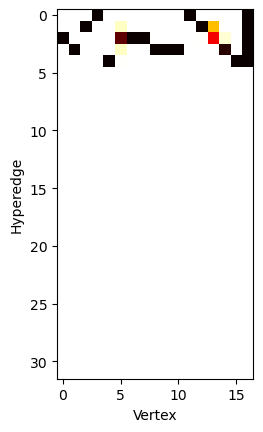

In [74]:
plot_incidence_matrix(im_target[0].cpu().numpy())

In [75]:
y = model(x)
y, loss, _ = model.align_incidence_matrix(y, im_target)

AttributeError: 'IRModel' object has no attribute 'align_incidence_matrix'

In [ ]:
# y = y.sigmoid()
y = y.detach().cpu().numpy()

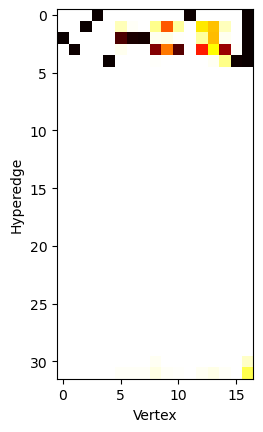

In [ ]:
plot_incidence_matrix(y[0])

In [76]:
def align_incidence_matrix(model, im_pred, im_true):

    loss, indices = model.loss(im_pred, im_true, return_indices=True)
    indices = torch.from_numpy(indices[:,1,...]).to(im_pred.device).long()
    indices = indices.unsqueeze(-1).expand(-1, -1, im_pred.shape[2])

    im_pred_aligned = torch.gather(im_pred, 1, indices)

    return im_pred_aligned, loss, indices

In [78]:
def convert_to_binary(im, threshold=0.5):
    return torch.where(im > threshold, 1, 0)

model.eval()

bs, num_edges, num_nodes = batch[1].shape

if 'refiner' in model.name:
    inputs, truth = batch
    e_t, v_t, i_t = model.net.get_initial(inputs)
    seq = model.net(inputs, e_t, v_t, i_t, t_skip=0, t_bp=model.config['iters_total'])[0]
    seq = [s.detach() for s in seq]
    aligned_seq = []
    for s in seq:
        aligned_s, _, _ = align_incidence_matrix(model, s, batch[1])
        aligned_seq.append(aligned_s)

    seq = torch.stack(aligned_seq, dim=0)
    pred = seq[-1]

    loss = LAP_loss(pred, truth, n=min(model.config['nray'], inputs.size(0)))

elif 'hhrm' in model.name:
    node_feats, im_truth = batch

    seq = model(node_feats, return_segments=True)

    im_pred = seq[-1]
    im_pred, loss, indices = model.align_incidence_matrix(im_pred, im_truth)
    # im_pred = im_pred.sigmoid()

    seq = torch.stack([model.align_incidence_matrix(s, im_truth)[0] for s in seq])
    # seq = seq.sigmoid()

else:
    raise NotImplementedError()

In [79]:
print(seq.shape)

torch.Size([48, 8, 32, 17])


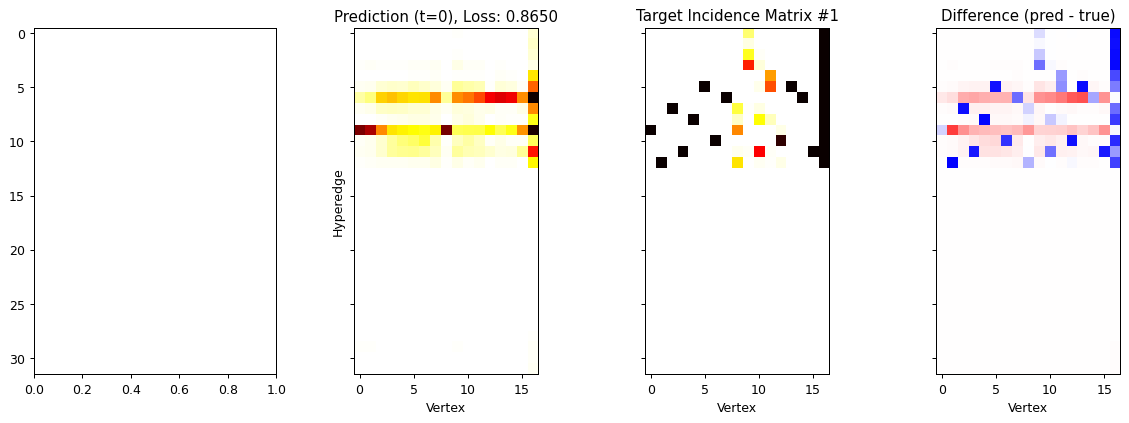

In [81]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(1, 4, figsize=(16, 5), sharey=True, dpi=90)

idx = 1
to_binary = False

def update(timestep):
    '''
    ax[0].clear()
    # Target sequence panel
    # target_im = target_seq[timestep][idx]
    # ax[0].imshow(1 - target_im.cpu().detach().numpy(), cmap='hot', vmin=0, vmax=1, interpolation='nearest')
    velocity = preds[timestep,idx] if timestep < preds.shape[0] else 0*preds[-1,idx]
    ax[0].imshow(1 - velocity[:,:-1].cpu().detach().numpy(), cmap='bwr', vmin=-1, vmax=1, interpolation='nearest')
    ax[0].set_title(f"Predicted v (t={timestep})")
    ax[0].set_ylabel("Hyperedge")
    ax[0].set_xlabel("Vertex")
    '''

    ax[1].clear()
    # Prediction panel
    im_pred = seq[timestep][idx]
    if to_binary:
        im_pred = convert_to_binary(im_pred, 0.5)
    im_pred_np = im_pred.cpu().detach().numpy()
    ax[1].imshow(1 - im_pred_np, cmap='hot', vmin=0, vmax=1, interpolation='nearest')
    ax[1].set_title(f"Prediction (t={timestep}), Loss: {loss[idx].mean():.4f}")
    ax[1].set_ylabel("Hyperedge")
    ax[1].set_xlabel("Vertex")

    ax[2].clear()
    # Target panel
    im_true = batch[1][idx].cpu().detach().numpy()
    ax[2].imshow(1 - im_true, cmap='hot', vmin=0, vmax=1, interpolation='nearest') 
    ax[2].set_title("Target Incidence Matrix #{}".format(idx))
    ax[2].set_xlabel("Vertex")

    ax[3].clear()
    # Difference panel
    diff = im_pred_np - im_true
    ax[3].imshow(diff, cmap='bwr', vmin=-1, vmax=1, interpolation='nearest')
    ax[3].set_title("Difference (pred - true)")
    ax[3].set_xlabel("Vertex")

ani = FuncAnimation(fig, update, frames=torch.arange(0, seq.shape[0], 1), interval=500)

HTML(ani.to_jshtml())